In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns

In [11]:
df=pd.read_csv(r"C:\Users\sristi singh\Downloads\credit_risk_dataset.csv")

In [12]:
df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


In [14]:
df.shape

(1000, 8)

<Axes: >

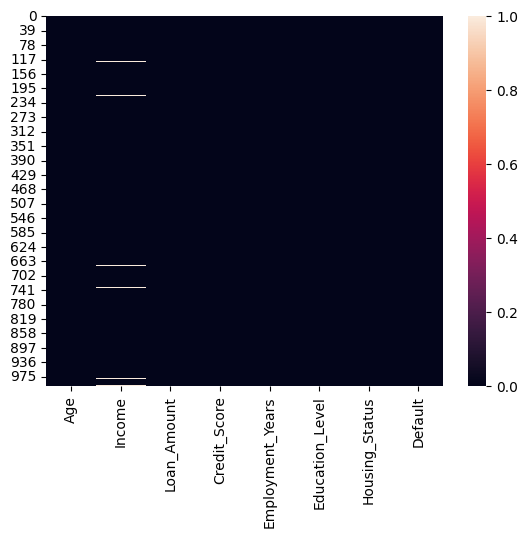

In [15]:
sns.heatmap(df.isnull())

In [16]:
df1=df.dropna()

In [17]:
df1_num_clm=df1.select_dtypes(include=['int','float'])

In [18]:
df1_cat_clm=df1.select_dtypes(include=['object'])

C:\Users\sristi singh\AppData\Local\Temp\ipykernel_17100\108456719.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df1_cat_clm=df1.select_dtypes(include=['object'])


C:\Users\sristi singh\AppData\Local\Temp\ipykernel_17100\1866581415.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Income'], color='r')
C:\Users\sristi singh\AppData\Local\Temp\ipykernel_17100\1866581415.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1_num_clm['Income'])


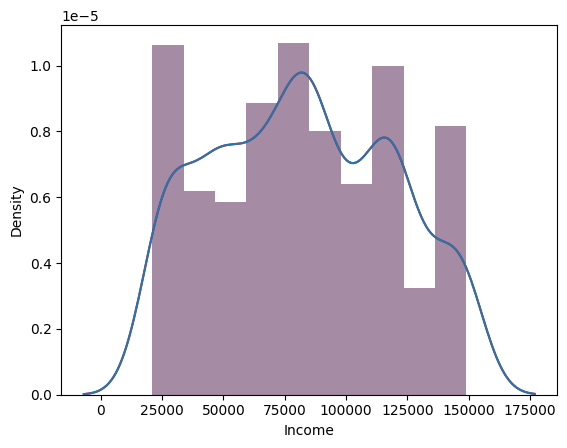

In [22]:
sns.distplot(df['Income'], color='r')
sns.distplot(df1_num_clm['Income'])
plt.show()

In [24]:
print(df.isnull().sum())

Age                  0
Income              15
Loan_Amount          0
Credit_Score         0
Employment_Years     0
Education_Level      0
Housing_Status       0
Default              0
dtype: int64


In [25]:
# ==========================
# MACHINE LEARNING MODEL
# ==========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Encode categorical columns
le = LabelEncoder()

df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Housing_Status"] = le.fit_transform(df["Housing_Status"])

# Define Features and Target
X = df.drop("Default", axis=1)
y = df["Default"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================
# LOGISTIC REGRESSION
# ==========================

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("========== Logistic Regression ==========")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print()

print(classification_report(y_test, pred_lr))

print("Confusion Matrix")
print(confusion_matrix(y_test, pred_lr))


# ==========================
# DECISION TREE
# ==========================

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("\n========== Decision Tree ==========")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print()

print(classification_report(y_test, pred_dt))

print("Confusion Matrix")
print(confusion_matrix(y_test, pred_dt))


# ==========================
# RANDOM FOREST
# ==========================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("\n========== Random Forest ==========")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print()

print(classification_report(y_test, pred_rf))

print("Confusion Matrix")
print(confusion_matrix(y_test, pred_rf))


# ==========================
# MODEL COMPARISON
# ==========================

lr_acc = accuracy_score(y_test, pred_lr)
dt_acc = accuracy_score(y_test, pred_dt)
rf_acc = accuracy_score(y_test, pred_rf)

comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

print("\n========== Model Comparison ==========")
print(comparison)

# ==========================
# FEATURE IMPORTANCE
# ==========================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n========== Feature Importance ==========")
print(importance)

# ==========================
# FEATURE IMPORTANCE GRAPH
# ==========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance using Random Forest")

plt.show()

# ==========================
# MODEL ACCURACY GRAPH
# ==========================

plt.figure(figsize=(6,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylim(0,1)

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.title("Machine Learning Model Comparison")

plt.show()

# ==========================
# FINAL CONCLUSION
# ==========================

best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("\n================ FINAL CONCLUSION ================\n")
print("The dataset was successfully preprocessed and used to train three machine learning models.")
print("The models were Logistic Regression, Decision Tree, and Random Forest.")
print("Each model was evaluated using Accuracy Score, Classification Report, and Confusion Matrix.")
print("Feature Importance was calculated using the Random Forest model.")
print()
print("Best Performing Model:")
print(best_model)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values